In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from synthetic_data_generator.graph import GraphBuilder, MuleNetworkSimulator, FraudRingInjector


In [2]:
print("Building fraud-injected transaction graph...")
injector = FraudRingInjector(seed=42)
graph_data = injector.build_injected_graph()

print(f"Nodes:      {graph_data['n_nodes']:,}")
print(f"Edges:      {graph_data['n_edges']:,}")
print(f"Legit:      {graph_data['n_legit']:,}")
print(f"Mule:       {graph_data['n_mule']:,}")
print(f"Fraud rate: {graph_data['fraud_rate']:.2%}")
print(f"Networks:   {len(graph_data['mule_networks'])}")


Building fraud-injected transaction graph...
📊 Injected graph: 5469 nodes | 16863 edges | Fraud rate: 8.58%
Nodes:      5,469
Edges:      16,863
Legit:      5,300
Mule:       169
Fraud rate: 8.58%
Networks:   20


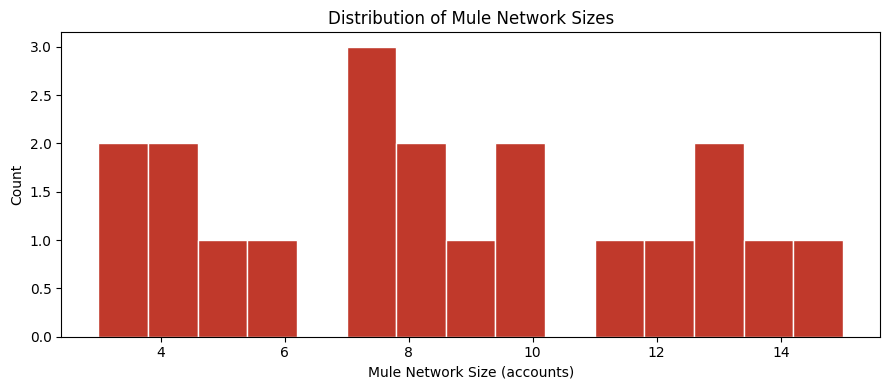

In [3]:
sizes = [net["size"] for net in graph_data["mule_networks"]]
plt.figure(figsize=(9, 4))
plt.hist(sizes, bins=15, color="#C0392B", edgecolor="white")
plt.xlabel("Mule Network Size (accounts)")
plt.ylabel("Count")
plt.title("Distribution of Mule Network Sizes")
plt.tight_layout()
plt.savefig("mule_network_sizes.png", dpi=150)
plt.show()

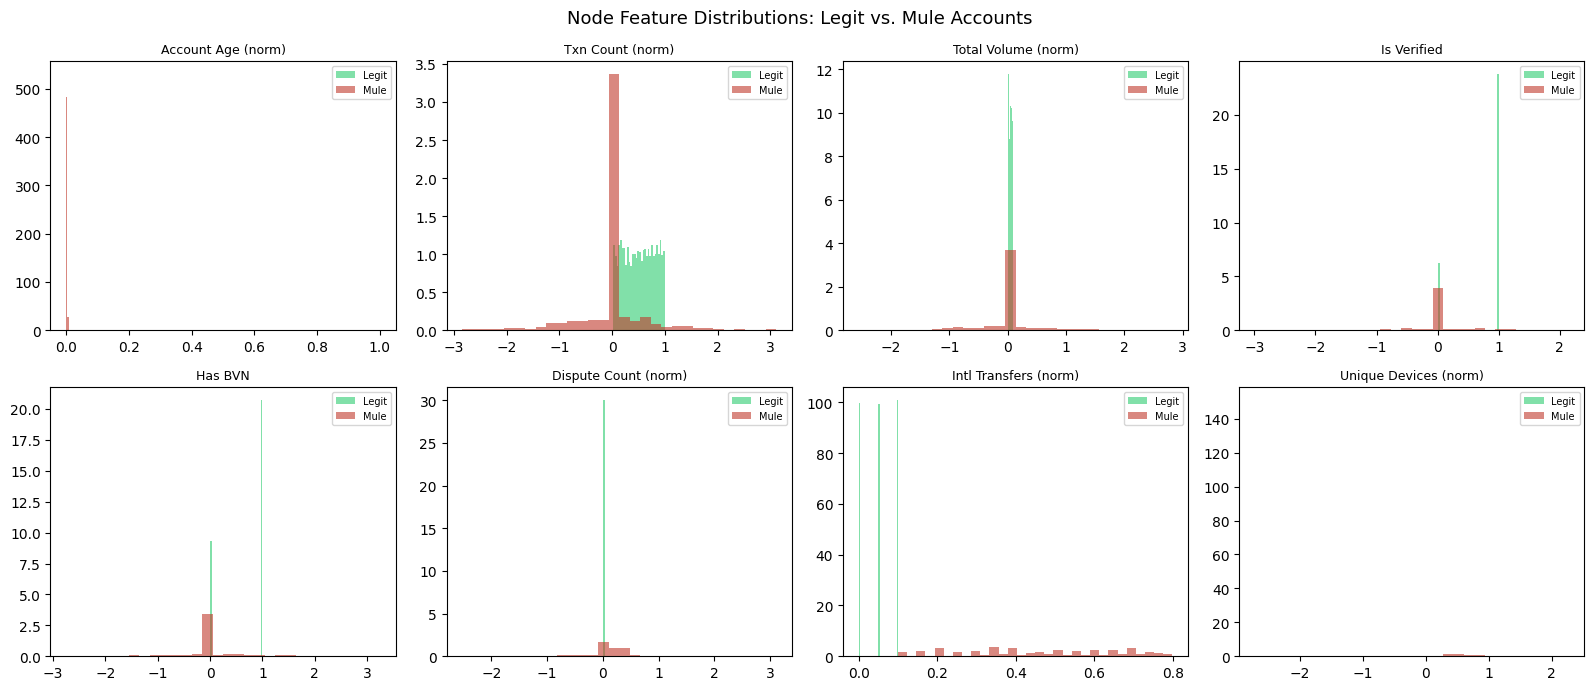

In [4]:
node_features = graph_data["node_features"]
labels        = graph_data["labels"]

legit_features = node_features[labels == 0]
mule_features  = node_features[labels == 1]

feature_names = [
    "Account Age (norm)", "Txn Count (norm)", "Total Volume (norm)",
    "Is Verified",        "Has BVN",          "Dispute Count (norm)",
    "Intl Transfers (norm)", "Unique Devices (norm)",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, ax in enumerate(axes.flatten()):
    if i >= len(feature_names):
        ax.set_visible(False)
        continue
    ax.hist(legit_features[:, i], bins=30, alpha=0.6, label="Legit",  color="#2ECC71", density=True)
    ax.hist(mule_features[:, i],  bins=30, alpha=0.6, label="Mule",   color="#C0392B", density=True)
    ax.set_title(feature_names[i], fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Node Feature Distributions: Legit vs. Mule Accounts", fontsize=13)
plt.tight_layout()
plt.savefig("node_feature_distributions.png", dpi=150)
plt.show()


Epoch 10 | Loss: 0.0509 | Val Acc: 0.9906
Epoch 20 | Loss: 0.0003 | Val Acc: 1.0000
Epoch 30 | Loss: 0.0001 | Val Acc: 1.0000


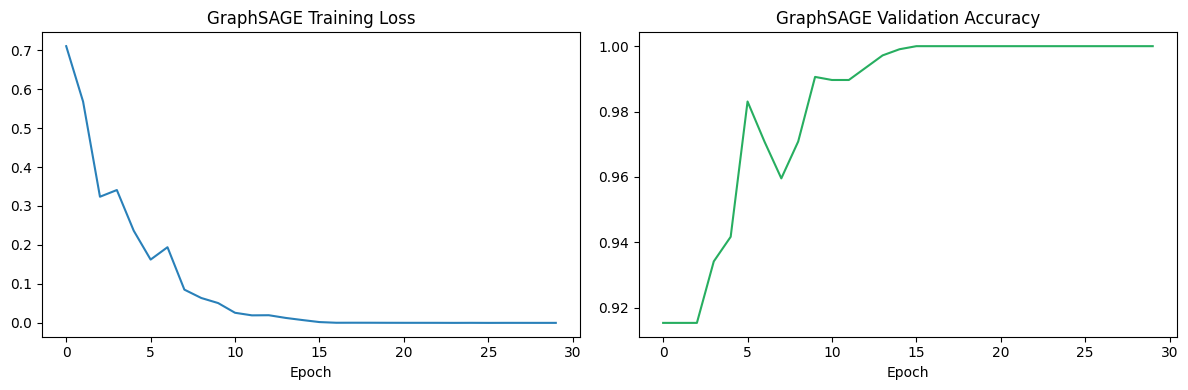

 GraphSAGE saved → checkpoints/graphsage.pt


In [5]:
import torch
import torch.nn.functional as F
from torch.optim import Adam
from app.models.graphsage import GraphSAGEFraudDetector

try:
    from torch_geometric.data import Data
    from torch_geometric.loader import NeighborLoader
    PYG = True
except ImportError:
    PYG = False
    print("  PyG not installed — skipping GNN training cell.")

if PYG:
    x          = torch.tensor(node_features, dtype=torch.float32)
    edge_index = torch.tensor(graph_data["edge_index"], dtype=torch.long)
    y          = torch.tensor(labels, dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.train_mask = torch.rand(len(y)) > 0.2
    data.val_mask   = ~data.train_mask

    model     = GraphSAGEFraudDetector(in_channels=64, out_channels=64)
    optimizer = Adam(model.parameters(), lr=0.01)

    train_losses, val_accs = [], []
    for epoch in range(30):
        model.train()
        optimizer.zero_grad()
        out  = model(data.x, data.edge_index)[data.train_mask]
        loss = F.binary_cross_entropy(out, y[data.train_mask].float().unsqueeze(1))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_out   = model(data.x, data.edge_index)[data.val_mask]
            val_preds = (val_out > 0.5).long().squeeze()
            val_acc   = (val_preds == y[data.val_mask]).float().mean().item()
            val_accs.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:02d} | Loss: {loss.item():.4f} | Val Acc: {val_acc:.4f}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, color="#2980B9")
    ax1.set_title("GraphSAGE Training Loss")
    ax1.set_xlabel("Epoch")

    ax2.plot(val_accs, color="#27AE60")
    ax2.set_title("GraphSAGE Validation Accuracy")
    ax2.set_xlabel("Epoch")
    plt.tight_layout()
    plt.savefig("graphsage_training.png", dpi=150)
    plt.show()

    torch.save(model.state_dict(), "../checkpoints/graphsage.pt")
    print(" GraphSAGE saved → checkpoints/graphsage.pt")


In [6]:
mule_simulator = MuleNetworkSimulator(seed=42)
networks       = mule_simulator.simulate_batch(n_networks=20)

hub_degrees = []
for net in networks:
    hub_degree = sum(1 for (src, dst) in net.edges if src == net.hub_account)
    hub_degrees.append(hub_degree)

print(f"\nMule Hub Degree Statistics:")
print(f"  Mean:   {np.mean(hub_degrees):.1f}")
print(f"  Max:    {np.max(hub_degrees)}")
print(f"  Median: {np.median(hub_degrees):.1f}")


Mule Hub Degree Statistics:
  Mean:   7.1
  Max:    12
  Median: 7.0
